# Quantum Grant Matching — R&D Notebook

**InclusiFund Research Vault**  
**Status:** Experimental  
**Data:** SYNTHETIC ONLY — no client data

---

## Overview

This notebook explores quantum-classical hybrid circuits for grant-applicant matching.

**Architecture:**
1. Classical feature encoder → normalised vector
2. Quantum circuit (variational ansatz) → compatibility score
3. Classical calibration → final ranking

**Origin Quantum Cloud:** When QPanda SDK is installed, circuits can run on
Origin Quantum's cloud simulators and real quantum hardware.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from quantum_grants.data.synthetic import generate_dataset
from quantum_grants.models.feature_encoder import encode_pair, encode_batch
from quantum_grants.circuits.grant_circuit import QuantumMatchCircuit
from quantum_grants.models.hybrid_matcher import HybridGrantMatcher

print('Modules loaded successfully')

Modules loaded successfully


## 1. Generate Synthetic Dataset

In [2]:
grants, applicants, labels = generate_dataset(n_grants=20, n_applicants=40, seed=42)

positive = sum(1 for l in labels if l.is_match)
negative = len(labels) - positive

print(f'Grants: {len(grants)}')
print(f'Applicants: {len(applicants)}')
print(f'Total pairs: {len(labels)}')
print(f'Positive matches: {positive} ({100*positive/len(labels):.1f}%)')
print(f'Negative matches: {negative} ({100*negative/len(labels):.1f}%)')

Generated 20 grants x 40 applicants = 800 pairs
Positive matches: 80 (10.0%)
Grants: 20
Applicants: 40
Total pairs: 800
Positive matches: 80 (10.0%)
Negative matches: 720 (90.0%)


## 2. Feature Encoding

In [3]:
# Encode a single pair
sample_grant = grants[0]
sample_applicant = applicants[0]

features = encode_pair(sample_grant, sample_applicant)
print(f'Grant: {sample_grant.grant_id} — {sample_grant.programme_name}')
print(f'Applicant: {sample_applicant.org_id} — {sample_applicant.org_name}')
print(f'\nFeature vector:')
print(f'  Eligibility:  {features.eligibility_binary}')
print(f'  Sector:       {features.sector_overlap}')
print(f'  Theme:        {features.theme_overlap}')
print(f'  Capacity:     {features.capacity_normalised}')
print(f'  Turnover:     {features.turnover_ratio}')
print(f'  Experience:   {features.experience_normalised}')
print(f'\nArray: {features.to_array()}')

Grant: G-0000 — Programme A
Applicant: ORG-0000 — Synthetic Org 0

Feature vector:
  Eligibility:  0.0
  Sector:       1.0
  Theme:        0.2
  Capacity:     0.85
  Turnover:     1.0
  Experience:   0.7333

Array: [0.     1.     0.2    0.85   1.     0.7333]


Feature matrix shape: (50, 6)


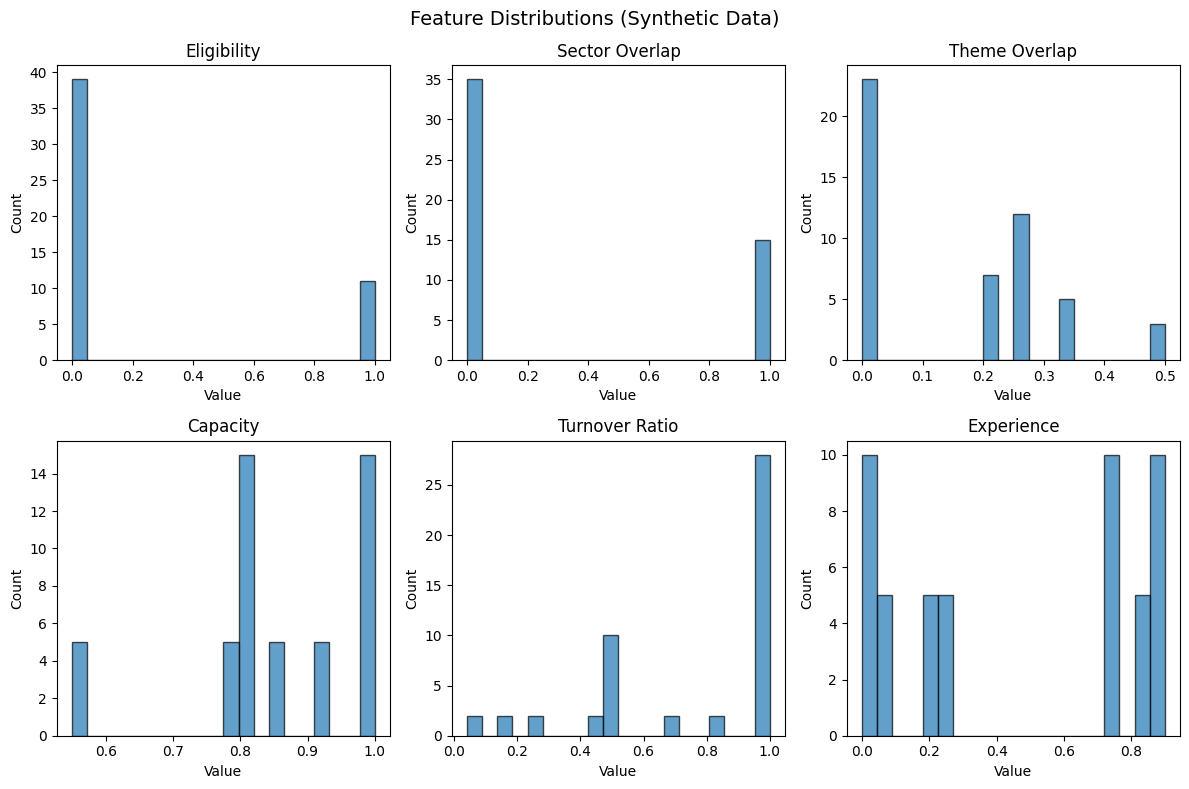

In [4]:
# Encode full batch and visualise feature distribution
feature_matrix = encode_batch(grants[:5], applicants[:10])
print(f'Feature matrix shape: {feature_matrix.shape}')

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
feature_names = ['Eligibility', 'Sector Overlap', 'Theme Overlap',
                 'Capacity', 'Turnover Ratio', 'Experience']

for i, (ax, name) in enumerate(zip(axes.flat, feature_names)):
    ax.hist(feature_matrix[:, i], bins=20, edgecolor='black', alpha=0.7)
    ax.set_title(name)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions (Synthetic Data)', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Quantum Circuit — Single Forward Pass

In [5]:
circuit = QuantumMatchCircuit(n_layers=2)

print(f'Qubits: {circuit.n_qubits}')
print(f'Layers: {circuit.n_layers}')
print(f'Parameters: {len(circuit.params)}')
print(f'QPanda available: {circuit._qpanda_available}')
print()

# Run on sample features
test_features = features.to_array()
score = circuit.forward(test_features)
print(f'Quantum score for sample pair: {score:.4f}')

/Users/royalreece/Desktop/Claude Code: AntiGravity Projects/InclusiFund-Research/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Qubits: 6
Layers: 2
Parameters: 36
QPanda available: True



NotImplementedError: QPanda forward pass not yet implemented. Use numpy simulation for now.

In [ ]:
# Test parameter sensitivity
scores = []
for _ in range(50):
    random_params = np.random.uniform(0, 2*np.pi, size=len(circuit.params))
    s = circuit.forward(test_features, random_params)
    scores.append(s)

plt.figure(figsize=(8, 4))
plt.hist(scores, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Quantum Score')
plt.ylabel('Count')
plt.title('Score Distribution Across Random Parameters')
plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold')
plt.legend()
plt.show()

print(f'Mean: {np.mean(scores):.4f}')
print(f'Std:  {np.std(scores):.4f}')

## 4. Hybrid Matcher — Ranking

In [ ]:
matcher = HybridGrantMatcher(n_layers=2, threshold=0.5)

# Rank top 5 grants for a sample applicant
sample_app = applicants[5]
print(f'Applicant: {sample_app.org_name}')
print(f'  Sector: {sample_app.sector}')
print(f'  Region: {sample_app.region}')
print(f'  Structure: {sample_app.legal_structure}')
print()

ranked = matcher.rank_grants(grants, sample_app, top_k=5)
print('Top 5 Grant Matches:')
for i, (grant, score) in enumerate(ranked, 1):
    print(f'  {i}. {grant.programme_name} (£{grant.min_award:,}–£{grant.max_award:,}) — Score: {score:.4f}')

## 5. Training (Small Run)

In [ ]:
from quantum_grants.training.trainer import train, TrainingConfig

config = TrainingConfig(
    n_layers=2,
    learning_rate=0.05,
    n_epochs=10,
    batch_size=16,
    n_grants=10,
    n_applicants=20,
)

logs = train(config)

In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = [l.epoch for l in logs]

ax1.plot(epochs, [l.loss for l in logs], 'b-o', markersize=4)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, [l.accuracy for l in logs], 'g-o', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

plt.suptitle('Quantum Grant Matcher — Training (Synthetic Data)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Origin Quantum Cloud (Future)

When `pyqpanda` is installed and Origin Quantum Cloud credentials are configured:

```python
import pyqpanda as pq

# Connect to Origin Quantum Cloud
machine = pq.QCloud()
machine.init_qvm("YOUR_API_KEY")

# Run circuit on real quantum hardware
qubits = machine.qAlloc_many(6)
cbits = machine.cAlloc_many(6)
prog = pq.QProg()

# Build circuit...
# Submit job...
# Get results...
```

**Safe for cloud:** This notebook uses only synthetic data.
No client information is transmitted to quantum cloud services.

---

## Next Steps

1. Install `pyqpanda` and test on Origin Quantum simulator
2. Hyperparameter sweep (layers, learning rate, batch size)
3. Compare quantum vs classical baseline (logistic regression)
4. Test on larger synthetic datasets
5. Document quantum advantage (if any)
6. Prepare production migration plan